In [2]:
import os
import zarr
import numpy as np
import tifffile as tiff
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.interpolate import Rbf
import cv2
import os
import json

In [3]:
data_path = '/root/capsule/data/'
# mouse_id = 767022
mouse_id = 767018


In [4]:
HCR_data_assets = [f for f in np.sort(os.listdir(data_path)) if f'HCR_{mouse_id}' in f and 'processed' in f]
round = 1
HCR_data_asset = HCR_data_assets[round-1]

json_file = [f'{data_path}{HCR_data_asset}/{f}' for f in os.listdir(f'{data_path}{HCR_data_asset}') if f.endswith('_ng.json')][0]
with open(json_file, 'r') as file:
    data = json.load(file)

scale_x = data['dimensions']['x'][0]*4e6
scale_y = data['dimensions']['y'][0]*4e6
scale_z = data['dimensions']['z'][0]*1e6

HCR_cell_centroids = np.load(data_path+HCR_data_asset+'/cell_body_segmentation/cell_centroids.npy')

HCR_cell_ids = HCR_cell_centroids[:,3]
HCR_cell_centroids = HCR_cell_centroids[:,:-1]

HCR_cell_centroids_df = pd.DataFrame()
HCR_cell_centroids_df['hcr_cell_id'] = HCR_cell_ids
HCR_cell_centroids_df['hcr_z'] = HCR_cell_centroids[:,0]
HCR_cell_centroids_df['hcr_y'] = HCR_cell_centroids[:,1]
HCR_cell_centroids_df['hcr_x'] = HCR_cell_centroids[:,2]
HCR_cell_centroids_df.set_index('hcr_cell_id', inplace=True)
HCR_cell_centroids_df.to_csv(f'/root/capsule/code/{mouse_id}_HCR_cell_centroids.csv')
HCR_cell_centroids_df = pd.read_csv(f'/root/capsule/code/{mouse_id}_HCR_cell_centroids.csv').set_index('hcr_cell_id',drop=True)
HCR_cell_centroids_df.head()

,hcr_z,hcr_y,hcr_x
hcr_cell_id,,,
1,33,756,182
2,107,296,103
3,116,194,113
4,116,320,90
5,117,184,104


In [5]:
scale_x, scale_y, scale_z

(0.9865341695582616, 0.9865341695582616, 1.0)

In [11]:
round = 1
HCR_data_asset = HCR_data_assets[round-1]
mixed_spots_file = f'{data_path}{HCR_data_asset}/image_spot_spectral_unmixing/mixed_spots_R{round}.pkl'
mixed_spots = pd.read_pickle(mixed_spots_file)

In [13]:
mixed_spots.head()

,spot_id,chan,chan_spot_id,cell_id,round,z,y,x,z_center,y_center,x_center,dist,r,chan_488_bg,chan_488_fg,chan_561_bg,chan_561_fg,chan_488_intensity,chan_561_intensity,over_thresh
0,1,488,1,72,1,138,507,298,-0.023393,0.011155,-0.013342,0.029149,0.658901,108.00,259.66666,457.04,2888.2034,151.66666,2431.1634,True
1,2,488,2,72,1,138,506,288,-0.400487,-0.457240,0.096084,0.615378,0.537691,119.00,333.29270,396.20,3105.9350,214.29270,2709.7350,True
2,3,488,3,72,1,138,503,290,0.426553,0.577998,-1.446055,1.614653,0.535639,118.04,310.47968,453.16,2433.1057,192.43968,1979.9457,True
3,4,488,4,72,1,138,503,284,0.101010,0.130287,0.293732,0.336833,0.639132,114.00,343.95123,336.08,1742.5447,229.95123,1406.4647,True
4,5,488,5,72,1,137,508,293,-0.226295,-0.339886,-0.049922,0.411369,0.497209,124.04,293.40650,554.28,3279.7397,169.36650,2725.4597,True


In [62]:
round = 1
HCR_data_asset = HCR_data_assets[round-1]
zarr_488 = zarr.open(f'{data_path}{HCR_data_asset}/image_tile_fusing/fused/channel_488.zarr/2')
zarr_488.shape

(1, 1, 1641, 1847, 1848)

In [16]:
HCR_cell_centroids_df

,hcr_z,hcr_y,hcr_x
hcr_cell_id,,,
1,33,756,182
2,107,296,103
3,116,194,113
4,116,320,90
5,117,184,104
...,...,...,...
108502,1362,1985,2305
108503,1362,2118,2305
108504,1363,2249,2246


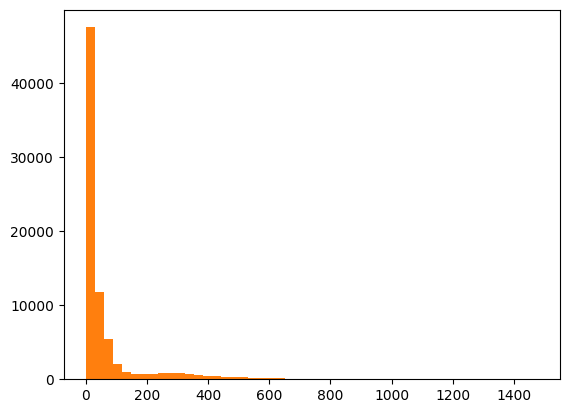

In [17]:
HCR_data_asset = HCR_data_assets[0]
hi_GFP_thr = -1
spots_488_file = f'{data_path}{HCR_data_asset}/image_spot_detection/channel_488_spots/spots.csv'
spots_488 = pd.read_csv(spots_488_file)
spot_488_counts = pd.DataFrame(spots_488['SEG_ID'].value_counts())
hi_GFP_ids = spot_488_counts.index.values[spot_488_counts['count']>hi_GFP_thr]
hi_GFP_df = HCR_cell_centroids_df.loc[hi_GFP_ids]

plt.hist(spot_488_counts['count'].values,50);
plt.hist(spot_488_counts.loc[spot_488_counts['count']>hi_GFP_thr,'count'].values,50);

In [18]:
landmarks_ext = pd.DataFrame()
# landmarks_ext[0] = ['Pt-'+str(i) for i in range(max_pt+1,max_pt+len(data)+1)]

landmarks_ext[0] = [f'id{id}' for id in hi_GFP_df.index.values]
# landmarks_ext[0] = ['Pt-'+str(int(i)) for i in range(len(data))]

landmarks_ext[1] = False
landmarks_ext[2] = hi_GFP_df['hcr_x'].values*scale_x
landmarks_ext[3] = hi_GFP_df['hcr_y'].values*scale_y
landmarks_ext[4] = hi_GFP_df['hcr_z'].values*scale_z
landmarks_ext[5] = hi_GFP_df['hcr_x'].values*scale_x
landmarks_ext[6] = hi_GFP_df['hcr_y'].values*scale_y
landmarks_ext[7] = hi_GFP_df['hcr_z'].values*scale_z
landmarks_ext.to_csv('/root/capsule/code/test.csv', index=False, header=False)
landmarks_ext.head()

,0,1,2,3,4,5,6,7
0,id95255,False,2042.125731,194.347231,1157.0,2042.125731,194.347231,1157.0
1,id22366,False,1808.317133,375.869519,578.0,1808.317133,375.869519,578.0
2,id70320,False,2084.546700,135.155181,975.0,2084.546700,135.155181,975.0
3,id47785,False,1060.524232,2114.142725,815.0,1060.524232,2114.142725,815.0
4,id98899,False,2050.018004,768.510118,1191.0,2050.018004,768.510118,1191.0


In [19]:
czstack_seg_data_asset = [f for f in np.sort(os.listdir(data_path)) if f'multiplane-ophys_{mouse_id}' in f and 'cortical-zstack-seg' in f][0]
czstack_masks_file = data_path+czstack_seg_data_asset+'/channel_0_ref_0/segmentation_masks.tif'
czstack_masks = tiff.imread(czstack_masks_file)

IndexError: list index out of range

In [28]:
czstack_masks_outline = np.zeros_like(czstack_masks,dtype=np.uint8)
kernel = np.ones((3, 3), np.uint8)
for i_plane, plane in enumerate(czstack_masks):
    ids = np.unique(plane)
    ids = ids[ids!=0]
    for id in ids:
        # Creates a uint8 array (1/0) that OpenCV can use
        mask = (plane==id).astype(np.uint8)
        eroded_mask = cv2.erode(mask, kernel, iterations=1)
        edge = cv2.subtract(mask, eroded_mask)==1
        czstack_masks_outline[i_plane][edge] += 1
tiff.imwrite(f'/root/capsule/code/{mouse_id}_seg_masks_outline.tif',czstack_masks_outline)

In [ ]:
czstack_cell_ids = np.unique(czstack_masks)
czstack_cell_ids = czstack_cell_ids[czstack_cell_ids!=0]
czstack_cell_centroids = np.zeros((len(czstack_cell_ids),3))
for i, czsid in tqdm(enumerate(czstack_cell_ids),total=len(czstack_cell_ids)):
    czstack_cell_centroids[i] = np.argwhere(czstack_masks == czsid).mean(axis=0)


100%|██████████| 868/868 [04:47<00:00,  3.02it/s]


In [9]:
czstack_cell_centroids_df = pd.DataFrame()
czstack_cell_centroids_df['czstack_cell_id'] = czstack_cell_ids
czstack_cell_centroids_df['czstack_z'] = czstack_cell_centroids[:,0]
czstack_cell_centroids_df['czstack_y'] = czstack_cell_centroids[:,1]
czstack_cell_centroids_df['czstack_x'] = czstack_cell_centroids[:,2]
czstack_cell_centroids_df.set_index('czstack_cell_id', inplace=True)
czstack_cell_centroids_df.to_csv(f'/root/capsule/code/{mouse_id}_czstack_cell_centroids.csv')
czstack_cell_centroids_df = pd.read_csv(f'/root/capsule/code/{mouse_id}_czstack_cell_centroids.csv').set_index('czstack_cell_id',drop=True)
czstack_cell_centroids_df.head()

,czstack_z,czstack_y,czstack_x
czstack_cell_id,,,
1,39.869342,489.039582,457.997251
2,43.118657,363.856925,313.635254
3,46.210516,438.379664,99.656872
4,41.520000,501.700000,450.660000
5,41.464912,508.535088,326.473684


In [66]:
czstack_cell_centroids_df = pd.read_csv(f'/root/capsule/code/{mouse_id}_czstack_cell_centroids.csv').set_index('czstack_cell_id',drop=True)
czstack_cell_centroids = np.vstack(czstack_cell_centroids_df[['czstack_z','czstack_y','czstack_x']].values)
# landmark_file = f'/root/capsule/code/{mouse_id}_landmarks.csv'
landmark_file = f'/root/capsule/code/{mouse_id}_landmarks.csv'

landmarks = pd.read_csv(landmark_file,header=None)
landmarks = landmarks.loc[landmarks[1]]
landmarks.head()
points_zstack = landmarks.loc[landmarks[1],[4,3,2]].values.astype(np.float32)
points_HCR = landmarks.loc[landmarks[1],[7,6,5]].values.astype(np.float32)

interp_zstacktoHCR_0 = Rbf(points_zstack[:, 0], points_zstack[:, 1], points_zstack[:, 2], points_HCR[:,0], function='thin_plate')
interp_zstacktoHCR_1 = Rbf(points_zstack[:, 0], points_zstack[:, 1], points_zstack[:, 2], points_HCR[:,1], function='thin_plate')
interp_zstacktoHCR_2 = Rbf(points_zstack[:, 0], points_zstack[:, 1], points_zstack[:, 2], points_HCR[:,2], function='thin_plate')

HCR_centroids_est = np.zeros_like(czstack_cell_centroids)

HCR_centroids_est[:,0] = interp_zstacktoHCR_0(czstack_cell_centroids[:, 0], czstack_cell_centroids[:, 1], czstack_cell_centroids[:, 2])/scale_z
HCR_centroids_est[:,1] = interp_zstacktoHCR_1(czstack_cell_centroids[:, 0], czstack_cell_centroids[:, 1], czstack_cell_centroids[:, 2])/scale_y
HCR_centroids_est[:,2] = interp_zstacktoHCR_2(czstack_cell_centroids[:, 0], czstack_cell_centroids[:, 1], czstack_cell_centroids[:, 2])/scale_x


In [67]:
HCR_cell_centroids_df

,hcr_z,hcr_y,hcr_x
hcr_cell_id,,,
1,163,270,72
2,163,267,71
3,163,279,71
4,164,276,75
5,165,286,72
...,...,...,...
84229,1401,1775,1783
84230,1406,1722,1842
84231,1407,1783,1803


In [68]:
HCR_cell_centroids_df

,hcr_z,hcr_y,hcr_x
hcr_cell_id,,,
1,163,270,72
2,163,267,71
3,163,279,71
4,164,276,75
5,165,286,72
...,...,...,...
84229,1401,1775,1783
84230,1406,1722,1842
84231,1407,1783,1803


In [71]:
np.vstack(HCR_cell_centroids_df.values)

array([[ 163,  270,   72],
       [ 163,  267,   71],
       [ 163,  279,   71],
       ...,
       [1407, 1783, 1803],
       [1407, 1777, 1794],
       [1410, 1830, 1816]], shape=(84233, 3))

,hcr_z,hcr_y,hcr_x,channel,cell_id,sum,count,mean,background
hcr_cell_id,,,,,,,,,
2,163,267,71,488,2,26100.0,269,97.026024,93.0
3,163,279,71,488,3,100834.0,1043,96.676895,93.0
4,164,276,75,488,4,18934.0,195,97.097435,93.0
5,165,286,72,488,5,61288.0,635,96.516530,93.0
8,167,286,77,488,8,87648.0,907,96.635060,93.0
...,...,...,...,...,...,...,...,...,...
84228,1400,1739,1825,488,84228,783620.0,6899,113.584580,97.0
84229,1401,1775,1783,488,84229,6667.0,67,99.507460,94.0
84230,1406,1722,1842,488,84230,21779.0,227,95.942730,97.0


In [95]:
remaining_hcr_cell_ids

[np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(8),
 np.int64(10),
 np.int64(11),
 np.int64(14),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(22),
 np.int64(23),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(36),
 np.int64(39),
 np.int64(40),
 np.int64(42),
 np.int64(43),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(57),
 np.int64(59),
 np.int64(62),
 np.int64(63),
 np.int64(64),
 np.int64(67),
 np.int64(69),
 np.int64(72),
 np.int64(74),
 np.int64(75),
 np.int64(76),
 np.int64(77),
 np.int64(79),
 np.int64(80),
 np.int64(81),
 np.int64(82),
 np.int64(83),
 np.int64(84),
 np.int64(86),
 np.int64(87),
 np.int64(88),
 np.int64(89),
 np.int64(90),
 np.int64(91),
 np.int64(92),
 np.int64(94),
 np.int64(95),
 np.int64(97),
 np.int64(100),
 np.int64(101),
 np.int64(102),
 np.int64(10

  0%|          | 0/839 [00:00<?, ?it/s]

100%|██████████| 839/839 [11:38<00:00,  1.20it/s]


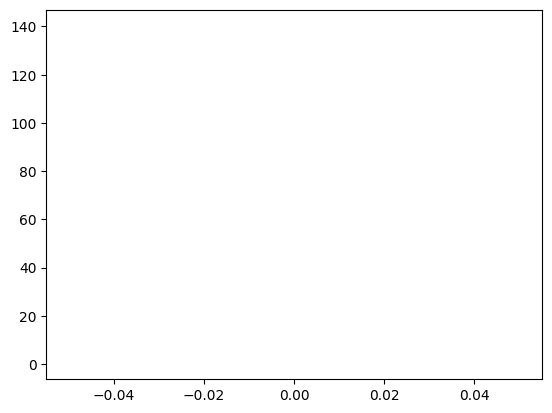

In [98]:
matched_cells_df = czstack_cell_centroids_df.copy()

matched_cells_df['hcr_cell_id'] = np.zeros(len(matched_cells_df))
matched_cells_df['hcr_x'] = np.zeros(len(matched_cells_df))
matched_cells_df['hcr_y'] = np.zeros(len(matched_cells_df))
matched_cells_df['hcr_z'] = np.zeros(len(matched_cells_df))
matched_cells_df['distance'] = np.zeros(len(matched_cells_df))

# HCR_cell_centroids_df = np.vstack(hi_GFP_df[['hcr_z','hcr_y','hcr_x']].values)
HCR_df = pd.merge(HCR_cell_centroids_df.reset_index(),cell_data_mean_488,left_on='hcr_cell_id', right_on='cell_id').set_index('hcr_cell_id')
for ind, czsid in tqdm(enumerate(matched_cells_df.index.values),total=len(matched_cells_df)):
    remaining_hcr_cell_ids = [id for id in HCR_df.index.values if id not in matched_cells_df['hcr_cell_id'].values]
    distances = np.linalg.norm(np.vstack(HCR_df.loc[remaining_hcr_cell_ids,['hcr_z','hcr_y','hcr_x']].values) - HCR_centroids_est[ind], axis=1)
    closest_indices = np.argsort(distances)[:5]
    best_index = closest_indices[np.argmax(HCR_df.loc[remaining_hcr_cell_ids,'mean'].values[closest_indices])]
    matched_cells_df.loc[czsid,'hcr_cell_id'] = remaining_hcr_cell_ids[best_index]
    matched_cells_df.loc[czsid,'hcr_x'] = HCR_df.loc[remaining_hcr_cell_ids,'hcr_x'].values[best_index]*scale_x
    matched_cells_df.loc[czsid,'hcr_y'] = HCR_df.loc[remaining_hcr_cell_ids,'hcr_y'].values[best_index]*scale_y
    matched_cells_df.loc[czsid,'hcr_z'] = HCR_df.loc[remaining_hcr_cell_ids,'hcr_z'].values[best_index]*scale_z
    matched_cells_df.loc[czsid,'distance'] = distances[best_index]
    plt.plot(distances[best_index],alpha=0.1,color='grey')
matched_cells_df = matched_cells_df.sort_values(by='distance').drop_duplicates(subset=['hcr_cell_id'], keep='first').reset_index()

In [99]:
matched_cells_df.to_csv(f'/root/capsule/code/{mouse_id}_initial_matched_cells.csv',index=False)
matched_cells_df = pd.read_csv(f'/root/capsule/code/{mouse_id}_initial_matched_cells.csv')
matched_cells_df

,czstack_cell_id,czstack_z,czstack_y,czstack_x,hcr_cell_id,hcr_x,hcr_y,hcr_z,distance
0,280,180.906571,453.172637,467.534293,19369.0,651.112552,711.291136,671.0,0.670750
1,288,178.641478,331.770842,156.071458,25327.0,1078.281847,815.863758,730.0,0.768944
2,67,82.032803,264.004181,390.294581,6336.0,811.917622,980.614965,485.0,0.927413
3,720,348.198546,319.902317,35.328941,72548.0,1191.733277,754.698640,1109.0,1.112781
4,413,224.263767,222.799559,86.184471,37887.0,1176.935264,926.355585,837.0,1.134801
...,...,...,...,...,...,...,...,...,...
834,828,437.481989,381.841041,262.492215,77030.0,870.123138,701.425795,1164.0,122.061700
835,831,439.298015,241.587658,144.192059,78756.0,997.386045,820.796429,1191.0,122.729189
836,835,441.455240,278.050218,324.186408,77560.0,817.836827,831.648305,1172.0,127.414389
837,838,446.456760,310.308161,171.978076,79068.0,992.453375,696.493124,1196.0,136.783528


In [100]:
landmark_file = f'/root/capsule/code/{mouse_id}_landmarks.csv'
landmarks = pd.read_csv(landmark_file,header=None)
landmarks = landmarks.loc[landmarks[1]]

landmarks_ext = pd.DataFrame()
# landmarks_ext[0] = ['Pt-'+str(i) for i in range(max_pt+1,max_pt+len(data)+1)]

landmarks_ext[0] = ['cz'+str(int(matched_cells_df['czstack_cell_id'].iloc[i]))+'-hcr'+str(int(matched_cells_df['hcr_cell_id'].iloc[i])) for i in range(len(matched_cells_df))]
# landmarks_ext[0] = ['Pt-'+str(int(i)) for i in range(len(data))]

landmarks_ext[1] = False
# landmarks_ext.loc[matched_cells_df['distance']<5,1] = True
landmarks_ext[2] = matched_cells_df['czstack_x'].values
landmarks_ext[3] = matched_cells_df['czstack_y'].values
landmarks_ext[4] = matched_cells_df['czstack_z'].values
landmarks_ext[5] = matched_cells_df['hcr_x'].values
landmarks_ext[6] = matched_cells_df['hcr_y'].values
landmarks_ext[7] = matched_cells_df['hcr_z'].values
landmarks_ext = pd.concat([landmarks_ext, landmarks])
landmarks_ext.to_csv(landmark_file.replace('.csv','_matched_ext.csv'), index=False, header=False)
landmarks_ext.head()

,0,1,2,3,4,5,6,7
0,cz280-hcr19369,False,467.534293,453.172637,180.906571,651.112552,711.291136,671.0
1,cz288-hcr25327,False,156.071458,331.770842,178.641478,1078.281847,815.863758,730.0
2,cz67-hcr6336,False,390.294581,264.004181,82.032803,811.917622,980.614965,485.0
3,cz720-hcr72548,False,35.328941,319.902317,348.198546,1191.733277,754.698640,1109.0
4,cz413-hcr37887,False,86.184471,222.799559,224.263767,1176.935264,926.355585,837.0
